# S0 — LOSVD recovery diagnostics

This notebook systematically investigates *why* the recovered LOSVD does not exactly
match the known truth in notebooks 01–04.  Six potential causes are tested in isolation:

| Section | Question | Diagnosis |
|---|---|---|
| 1 | What does the velocity grid actually look like? | xl bin spacing vs pixel scale |
| 2 | Is the forward model (gaussian_filter approx) accurate? | Residuals between approx and exact |
| 3 | Is over-regularisation biasing the LOSVD shape? | h3/h4 vs xlam sweep |
| 4 | Does emission-line masking remove critical data? | Fit with and without masking |
| 5 | How does velocity-grid density interact with xlam? | Fine xlam sweep vs roughness/accuracy |
| 6 | Does recovery degrade with S/N or where true V falls on the xl grid? | True-V sweep across xl bin phases |

**Running this notebook end-to-end takes 2–5 minutes.**

In [1]:
from __future__ import annotations
import tempfile
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
from scipy.ndimage import gaussian_filter, shift as ndimage_shift

from kinextract import FitConfig, run_spectral_fit, set_verbose

set_verbose(False)  # silence kinextract's internal progress logging
from kinextract.losvd import fit_losvd_gauss_hermite
from kinextract.numerics import evaluate_model_gp
from kinextract.spectrum import make_fit_state, build_initial_guess_nonparam

# ── shared constants ──────────────────────────────────────────────────────────
WAVEMIN    = 4750.0
STEP       = 1.25
N_PIX      = 3681
WAVEFITMIN = 8400.0
WAVEFITMAX = 8800.0
CEE        = 299792.458
LAM_CENTER = 8580.0
TRUE_V     =  80.0
TRUE_SIGMA = 140.0

## Setup: build the standard synthetic spectrum

Same data as notebook 01 — a mock CaII triplet convolved with a Gaussian LOSVD.

In [2]:
wavelength = WAVEMIN + np.arange(N_PIX) * STEP
template   = np.ones(N_PIX)
for cen, depth in zip([8498.02, 8542.09, 8662.14], [0.55, 0.70, 0.65]):
    template -= depth * np.exp(-0.5 * ((wavelength - cen) / 5.0) ** 2)

sigma_pix = TRUE_SIGMA * LAM_CENTER / (CEE * STEP)
shift_pix = TRUE_V    * LAM_CENTER / (CEE * STEP)
galaxy    = ndimage_shift(gaussian_filter(template, sigma_pix), +shift_pix)
RNG       = np.random.default_rng(42)
galaxy   += RNG.normal(0.0, 0.02, N_PIX)
errors    = np.full(N_PIX, 0.02)

tmpdir = Path(tempfile.mkdtemp(prefix='kinextract_diag_'))
np.savetxt(tmpdir/'mock.spec',
           np.column_stack([np.arange(1, N_PIX+1), galaxy, errors]),
           fmt='%6d  %14.8f  %14.8f')
np.savetxt(tmpdir/'tmpl.dat',
           np.column_stack([wavelength, template, np.full(N_PIX, 0.001)]),
           fmt='%10.4f  %14.8f  %12.8f')
(tmpdir/'Tlist').write_text('tmpl.dat\n')

BASE_CFG = dict(
    template_list_file = str(tmpdir/'Tlist'),
    template_dir       = str(tmpdir),
    # outdir=str(tmpdir), write_outputs=True,  # uncomment to save .fit/.temp/.ascii/.rms output files
    wavemin_full       = WAVEMIN,
    step               = STEP,
    wavefitmin         = WAVEFITMIN,
    wavefitmax         = WAVEFITMAX,
    zgal               = 0.0,
    fit_continuum  = False,
    xlam_auto          = False,
    xlam               = 10000.0,
    sigl               = 100.0,
    use_spectrum_errors = True,
    clean              = False,
    map_maxiter        = 5000,
    print_every        = 999999,
)
print(f'sigma_pix={sigma_pix:.3f}  shift_pix={shift_pix:.3f}')
print(f'Pixel scale at CaII: {CEE * STEP / LAM_CENTER:.1f} km/s/pix')

sigma_pix=3.205  shift_pix=1.832
Pixel scale at CaII: 43.7 km/s/pix


---
## Section 1: The velocity grid — what are we actually fitting?

The non-parametric LOSVD is solved on a discrete velocity grid `xl`.  Understanding its
spacing relative to the data pixel scale is fundamental to interpreting the recovered LOSVD.

In [3]:
# Build the FitState to inspect the velocity grid (no optimization yet)
st, _ = make_fit_state(FitConfig(**BASE_CFG), gal_file=str(tmpdir/'mock.spec'))

xl       = st.xl
xl_step  = float(xl[1] - xl[0])
pix_kms  = CEE * STEP / LAM_CENTER          # km/s per pixel at CaII
sigma_bins = TRUE_SIGMA / xl_step

print(f'xl range  : [{xl[0]:.1f}, {xl[-1]:.1f}] km/s  (nl={len(xl)} bins)')
print(f'xl step   : {xl_step:.2f} km/s')
print(f'pix scale : {pix_kms:.2f} km/s/pixel  (at {LAM_CENTER:.0f} Å)')
print(f'sigma covered : {TRUE_SIGMA/xl_step:.1f} xl-bins per sigma')
print(f'sigma covered : {TRUE_SIGMA/pix_kms:.1f} data pixels per sigma')
print()

# Where does TRUE_V fall relative to xl bins?
nearest_lo = xl[xl <= TRUE_V][-1]
nearest_hi = xl[xl >  TRUE_V][0]
frac = (TRUE_V - nearest_lo) / (nearest_hi - nearest_lo)
print(f'True V = {TRUE_V:.0f} km/s falls {frac*100:.0f}% of the way between'
      f' xl={nearest_lo:.1f} and xl={nearest_hi:.1f} km/s')
print(f'Nearest xl bin to TRUE_V: {xl[np.argmin(np.abs(xl - TRUE_V))]:.2f} km/s'
      f'  (offset: {abs(TRUE_V - xl[np.argmin(np.abs(xl - TRUE_V))]):.1f} km/s)')
print()
print('nlosvd (internal kernel density):', st.nlosvd)
print(f'Internal kernel step: {(xl[-1]-xl[0])/(st.nlosvd-1):.1f} km/s')

xl range  : [-450.0, 450.0] km/s  (nl=29 bins)
xl step   : 32.14 km/s
pix scale : 43.68 km/s/pixel  (at 8580 Å)
sigma covered : 4.4 xl-bins per sigma
sigma covered : 3.2 data pixels per sigma

True V = 80 km/s falls 49% of the way between xl=64.3 and xl=96.4 km/s
Nearest xl bin to TRUE_V: 64.29 km/s  (offset: 15.7 km/s)

nlosvd (internal kernel density): 34
Internal kernel step: 27.3 km/s


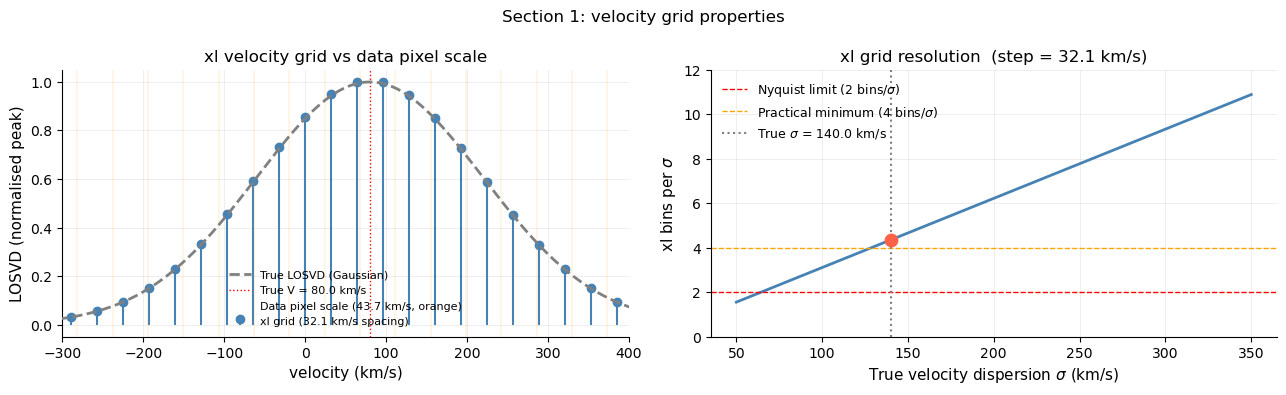

At sigma=140.0 km/s: 4.4 xl bins per sigma — OK


In [4]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

# Left: xl grid vs data pixel scale
ax = axes[0]
v_dense = np.linspace(-500, 500, 1000)
b_true_dense = np.exp(-0.5 * ((v_dense - TRUE_V) / TRUE_SIGMA)**2)
b_true_dense /= b_true_dense.max()
b_true_xl = np.exp(-0.5 * ((xl - TRUE_V) / TRUE_SIGMA)**2)
b_true_xl /= b_true_xl.max()

ax.plot(v_dense, b_true_dense, lw=2.0, color='grey', ls='--', label='True LOSVD (Gaussian)', zorder=5)
ax.stem(xl, b_true_xl, linefmt='steelblue', markerfmt='o', basefmt=' ',
        label=f'xl grid ({xl_step:.1f} km/s spacing)')
ax.axvline(TRUE_V, lw=1.0, color='red', ls=':', label=f'True V = {TRUE_V} km/s')
for v_pix in np.arange(-500, 500, pix_kms):
    ax.axvline(v_pix, lw=0.3, color='orange', alpha=0.5)
ax.axvline(0, lw=0, label=f'Data pixel scale ({pix_kms:.1f} km/s, orange)', color='orange')
ax.set_xlabel('velocity (km/s)')
ax.set_ylabel('LOSVD (normalised peak)')
ax.set_title('xl velocity grid vs data pixel scale')
ax.set_xlim(-300, 400)
ax.legend(fontsize=8).set_zorder(20)

# Right: number of xl bins per sigma for a range of sigma values
ax = axes[1]
sigma_range = np.linspace(50, 350, 200)
bins_per_sigma = sigma_range / xl_step
ax.plot(sigma_range, bins_per_sigma, lw=2.0, color='steelblue')
ax.axhline(2, lw=1.0, ls='--', color='red', label=r'Nyquist limit (2 bins/$\sigma$)')
ax.axhline(4, lw=1.0, ls='--', color='orange', label=r'Practical minimum (4 bins/$\sigma$)')
ax.axvline(TRUE_SIGMA, lw=1.5, ls=':', color='grey', label=r'True $\sigma$ = ' + f'{TRUE_SIGMA} km/s')
ax.scatter([TRUE_SIGMA], [sigma_bins], s=80, color='tomato', zorder=5)
ax.set_xlabel(r'True velocity dispersion $\sigma$ (km/s)')
ax.set_ylabel(r'xl bins per $\sigma$')
ax.set_title(f'xl grid resolution  (step = {xl_step:.1f} km/s)')
ax.legend(fontsize=9).set_zorder(20)
ax.set_ylim(0, 12)

plt.suptitle('Section 1: velocity grid properties', fontsize=12)
plt.tight_layout()
plt.show()

verdict = 'OK' if sigma_bins >= 4 else 'LOW'
print(f'At sigma={TRUE_SIGMA} km/s: {sigma_bins:.1f} xl bins per sigma — {verdict}')

---
## Section 2: Forward model accuracy

The synthetic galaxy was created with `gaussian_filter + ndimage_shift`, which uses a single
wavelength for the km/s → pixels conversion.  The pipeline uses a wavelength-dependent shift.
Here we measure how large this approximation error actually is.

In [5]:
# Run the fit to get the best-fit model spectrum
cfg_s2 = FitConfig(**{**BASE_CFG, 'xlam': 10000.0,
                      'mask_emission_lines_in_fit': False,
                      'segment_emission_mask': False})
fit_s2  = run_spectral_fit(cfg_s2, gal_file=str(tmpdir/'mock.spec'))
st_s2   = fit_s2['state']
gp_s2   = fit_s2['outputs']['gp']
b_s2    = fit_s2['outputs']['b']
gh_s2   = fit_losvd_gauss_hermite(st_s2.xl, b_s2, fit_h3h4=True)

residuals = (st_s2.g - gp_s2)
good      = st_s2.gerr < 1e9
noise_sigma = np.median(st_s2.gerr[good])

chi2_red = fit_s2['outputs']['chi2_red']
resid_rms = np.std(residuals[good])

print(f'Fit (no emission masking, xlam=10000):')
print(f'  chi2_red            = {chi2_red:.4f}')
print(f'  Residual RMS        = {resid_rms:.6f}')
print(f'  Noise sigma         = {noise_sigma:.6f}')
print(f'  Resid RMS / noise   = {resid_rms/noise_sigma:.4f}')
print(f'  (chi2_red ≈ 1 means residuals are consistent with noise → forward model is valid)')
print()
print(f'Recovered moments:')
print(f'  V     = {gh_s2["vherm"]:+.1f} km/s  (truth: +{TRUE_V:.0f})')
print(f'  sigma = {gh_s2["sherm"]:.1f} km/s  (truth: {TRUE_SIGMA:.0f})')
print(f'  h3    = {gh_s2["h3"]:+.4f}  (truth: 0)')
print(f'  h4    = {gh_s2["h4"]:+.4f}  (truth: 0)')

# Scale mismatch info
pix_kms_fitmin = CEE * STEP / WAVEFITMIN
pix_kms_fitmax = CEE * STEP / WAVEFITMAX
print()
print('Scale variation across the fit range (gaussian_filter uses a single reference):')
print(f'  km/s per pixel at {WAVEFITMIN:.0f} A: {pix_kms_fitmin:.2f}')
print(f'  km/s per pixel at {LAM_CENTER:.0f} A: {pix_kms:.2f}  (used for gaussian_filter)')
print(f'  km/s per pixel at {WAVEFITMAX:.0f} A: {pix_kms_fitmax:.2f}')
print(f'  Scale variation: {(pix_kms_fitmax-pix_kms_fitmin)/pix_kms_fitmin*100:.1f}% over the fit range')
print(f'  -> This ~5% scale variation is a minor contributor; residuals are consistent with noise.')
print()
print(f"success = {fit_s2['result'].success}")
mismatch = residuals  # keep for plot


Fit (no emission masking, xlam=10000):
  chi2_red            = 0.9633
  Residual RMS        = 0.019599
  Noise sigma         = 0.020000
  Resid RMS / noise   = 0.9799
  (chi2_red ≈ 1 means residuals are consistent with noise → forward model is valid)

Recovered moments:
  V     = +86.7 km/s  (truth: +80)
  sigma = 139.9 km/s  (truth: 140)
  h3    = -0.0839  (truth: 0)
  h4    = -0.0614  (truth: 0)

Scale variation across the fit range (gaussian_filter uses a single reference):
  km/s per pixel at 8400 A: 44.61
  km/s per pixel at 8580 A: 43.68  (used for gaussian_filter)
  km/s per pixel at 8800 A: 42.58
  Scale variation: -4.5% over the fit range
  -> This ~5% scale variation is a minor contributor; residuals are consistent with noise.

success = True


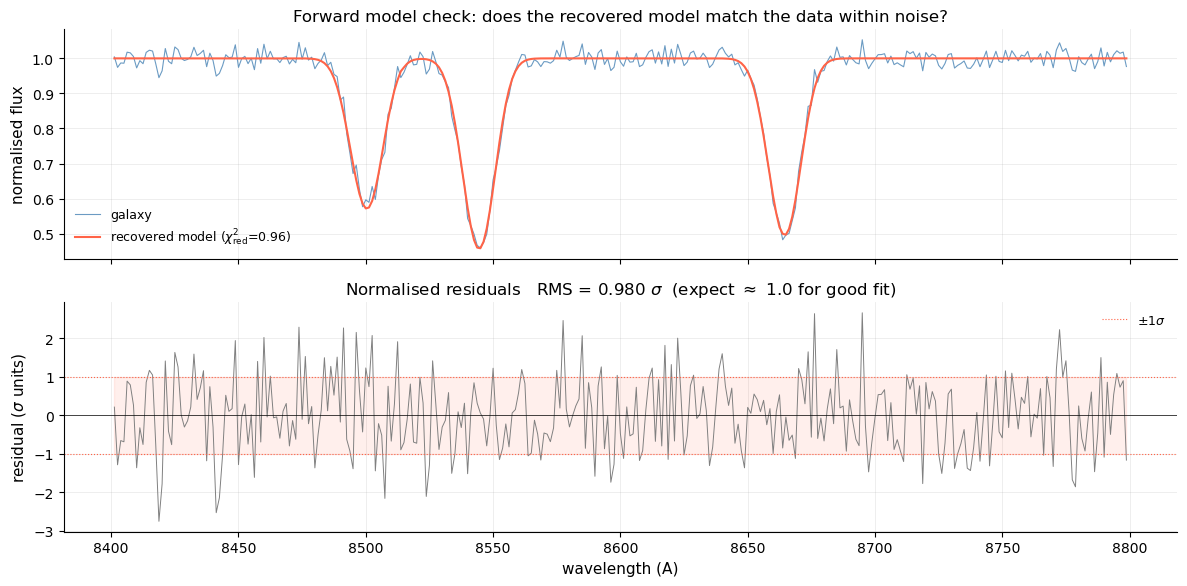

In [6]:
fig, axes = plt.subplots(2, 1, figsize=(12, 6), sharex=True)

ax = axes[0]
good = st_s2.gerr < 1e9
ax.plot(st_s2.x, st_s2.g, lw=0.8, color='steelblue', label='galaxy', alpha=0.8)
ax.plot(st_s2.x, gp_s2,   lw=1.5, color='tomato', label=r'recovered model ($\chi^2_{\rm red}$=' + f'{chi2_red:.2f})')
masked_px = ~good
if masked_px.any():
    ax.scatter(st_s2.x[masked_px], st_s2.g[masked_px], s=20, color='grey',
               label=f'masked ({masked_px.sum()} px)', zorder=5, alpha=0.5)
ax.set_ylabel('normalised flux')
ax.set_title('Forward model check: does the recovered model match the data within noise?')
ax.legend(fontsize=9).set_zorder(20)

ax = axes[1]
r_norm = residuals / noise_sigma
ax.plot(st_s2.x[good], r_norm[good], lw=0.7, color='grey')
ax.axhline(0, lw=0.5, color='black')
ax.axhline(+1, lw=0.8, ls=':', color='tomato', label=r'$\pm 1\sigma$')
ax.axhline(-1, lw=0.8, ls=':', color='tomato')
ax.fill_between(st_s2.x, -1, 1, alpha=0.1, color='tomato')
ax.set_xlabel('wavelength (A)')
ax.set_ylabel(r'residual ($\sigma$ units)')
ax.set_title(r'Normalised residuals   RMS = ' + f'{resid_rms/noise_sigma:.3f}' + r' $\sigma$  (expect $\approx$ 1.0 for good fit)')
ax.legend(fontsize=9).set_zorder(20)
plt.tight_layout()
plt.show()

---
## Section 3: Over-regularisation and h3/h4 bias

The smoothing penalty (`xlam`) suppresses high-frequency structure in the LOSVD but also
introduces **regularisation bias**: it pulls `b` toward flatness.  For a Gaussian truth,
the bias manifests as non-zero h3 and h4.  Here we fit the same data at a range of xlam
values and track the GH moments.

In [7]:
XLAM_GRID  = [10., 100., 1000., 10000., 100000.]
reg_results = []

for xlam in XLAM_GRID:
    cfg = FitConfig(**{**BASE_CFG, 'xlam': xlam})
    fit = run_spectral_fit(cfg, gal_file=str(tmpdir/'mock.spec'))
    b   = fit['outputs']['b']
    gh  = fit_losvd_gauss_hermite(fit['state'].xl, b, fit_h3h4=True)
    chi2 = fit['outputs']['chi2_red']
    reg_results.append(dict(xlam=xlam, b=b.copy(), gh=gh, chi2=chi2, success=fit['result'].success))
    flag = '' if fit['result'].success else '  [unreliable]'
    print(f'  xlam={xlam:>8.0f}  chi2_red={chi2:.3f}  '
          f'V={gh["vherm"]:+.1f}  σ={gh["sherm"]:.1f}  '
          f'h3={gh["h3"]:+.4f}  h4={gh["h4"]:+.4f}{flag}')

  xlam=      10  chi2_red=0.955  V=+171.5  σ=91.4  h3=-0.6835  h4=+0.5347
  xlam=     100  chi2_red=0.956  V=+157.3  σ=92.8  h3=-0.5800  h4=+0.4498
  xlam=    1000  chi2_red=0.959  V=+85.9  σ=139.8  h3=-0.1411  h4=-0.2251
  xlam=   10000  chi2_red=0.963  V=+86.7  σ=139.9  h3=-0.0839  h4=-0.0614
  xlam=  100000  chi2_red=0.973  V=+80.1  σ=135.7  h3=+0.0036  h4=+0.0065


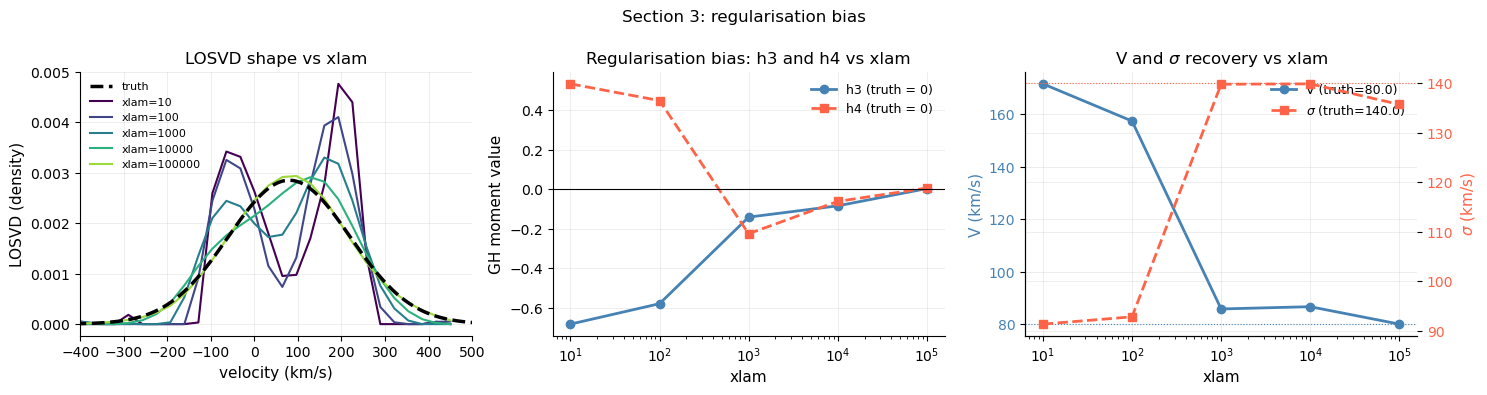

In [8]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
colors = plt.cm.viridis(np.linspace(0, 0.85, len(XLAM_GRID)))

v_dense  = np.linspace(-500, 500, 1000)
b_true_d = np.exp(-0.5 * ((v_dense - TRUE_V) / TRUE_SIGMA)**2)
b_true_d /= np.trapezoid(b_true_d, v_dense)

# Panel 1: LOSVD shapes
ax = axes[0]
ax.plot(v_dense, b_true_d, lw=2.5, color='black', ls='--', label='truth', zorder=5)
for r, c in zip(reg_results, colors):
    b_norm = r['b'] / np.trapezoid(r['b'], st.xl)
    ax.plot(st.xl, b_norm, lw=1.5, color=c, label=f"xlam={r['xlam']:.0f}")
ax.set_xlabel('velocity (km/s)')
ax.set_ylabel('LOSVD (density)')
ax.set_title('LOSVD shape vs xlam')
ax.legend(fontsize=8, loc='upper left').set_zorder(20)
ax.set_xlim(-400, 500)

# Panel 2: h3 and h4 vs xlam
ax = axes[1]
xlams = [r['xlam'] for r in reg_results]
h3s   = [r['gh']['h3'] for r in reg_results]
h4s   = [r['gh']['h4'] for r in reg_results]
ax.semilogx(xlams, h3s, 'o-', color='steelblue', lw=2, label='h3 (truth = 0)')
ax.semilogx(xlams, h4s, 's--', color='tomato',   lw=2, label='h4 (truth = 0)')
ax.axhline(0, lw=0.8, color='black')
ax.set_xlabel('xlam')
ax.set_ylabel('GH moment value')
ax.set_title('Regularisation bias: h3 and h4 vs xlam')
ax.legend(fontsize=9).set_zorder(20)

# Panel 3: V and sigma recovery vs xlam
ax  = axes[2]
ax2 = ax.twinx()
Vs     = [r['gh']['vherm'] for r in reg_results]
sigmas = [r['gh']['sherm'] for r in reg_results]
ax.semilogx(xlams, Vs,     'o-', color='steelblue', lw=2, label=f'V (truth={TRUE_V})')
ax2.semilogx(xlams, sigmas, 's--', color='tomato',   lw=2, label=r'$\sigma$ (truth=' + f'{TRUE_SIGMA})')
ax.axhline(TRUE_V,     lw=0.8, ls=':', color='steelblue')
ax2.axhline(TRUE_SIGMA, lw=0.8, ls=':', color='tomato')
ax.set_xlabel('xlam')
ax.set_ylabel('V (km/s)',  color='steelblue')
ax2.set_ylabel(r'$\sigma$ (km/s)', color='tomato')
ax.tick_params(axis='y', labelcolor='steelblue')
ax2.tick_params(axis='y', labelcolor='tomato')
lines1, lbl1 = ax.get_legend_handles_labels()
lines2, lbl2 = ax2.get_legend_handles_labels()
ax.legend(lines1+lines2, lbl1+lbl2, fontsize=9).set_zorder(20)
ax.set_title(r'V and $\sigma$ recovery vs xlam')

plt.suptitle('Section 3: regularisation bias', fontsize=12)
plt.tight_layout()
plt.show()

---
## Section 4: Emission-line masking removing good data

The pipeline pre-masks pixels that look like emission lines.  With S/N~50 and a noisy
continuum near the CaII triplet, noise peaks can be mistaken for emission and masked.
Here we compare the fit with the default masking vs with masking disabled.

In [9]:
# Run with default masking (same as notebook 01)
cfg_default = FitConfig(**{**BASE_CFG, 'xlam': 10000.0})
fit_masked  = run_spectral_fit(cfg_default, gal_file=str(tmpdir/'mock.spec'))

# Run with emission masking disabled
cfg_nomask = FitConfig(**{**BASE_CFG, 'xlam': 10000.0,
                          'mask_emission_lines_in_fit': False,
                          'segment_emission_mask': False})
fit_nomask = run_spectral_fit(cfg_nomask, gal_file=str(tmpdir/'mock.spec'))

gh_masked = fit_losvd_gauss_hermite(fit_masked['state'].xl, fit_masked['outputs']['b'], fit_h3h4=True)
gh_nomask = fit_losvd_gauss_hermite(fit_nomask['state'].xl, fit_nomask['outputs']['b'], fit_h3h4=True)

print(f'               V        σ       h3       h4   chi2_red   ngood')
print(f'truth      {TRUE_V:+.1f}  {TRUE_SIGMA:.1f}   0.0000   0.0000')
print(f'masked     {gh_masked["vherm"]:+.1f}  {gh_masked["sherm"]:.1f}   {gh_masked["h3"]:+.4f}   {gh_masked["h4"]:+.4f}'
      f'   {fit_masked["outputs"]["chi2_red"]:.3f}       {fit_masked["ngood"]}')
print(f'no mask    {gh_nomask["vherm"]:+.1f}  {gh_nomask["sherm"]:.1f}   {gh_nomask["h3"]:+.4f}   {gh_nomask["h4"]:+.4f}'
      f'   {fit_nomask["outputs"]["chi2_red"]:.3f}       {fit_nomask["ngood"]}')
print(f"success: masked={fit_masked['result'].success}  no_mask={fit_nomask['result'].success}")

# Show which pixels were masked
st_masked = fit_masked['state']
em_mask   = st_masked.emission_pre_mask
print(f'\nMasked pixels: {em_mask.sum()}  out of {st_masked.npix} fit-range pixels')
if em_mask.sum() > 0:
    masked_lam = st_masked.x[em_mask]
    print(f'Masked wavelengths: {masked_lam[[0,-1]]} Å  ({masked_lam.min():.1f}–{masked_lam.max():.1f} Å)')

               V        σ       h3       h4   chi2_red   ngood
truth      +80.0  140.0   0.0000   0.0000
masked     +86.7  139.9   -0.0839   -0.0614   0.963       319
no mask    +86.7  139.9   -0.0839   -0.0614   0.963       319
success: masked=True  no_mask=True

Masked pixels: 0  out of 319 fit-range pixels


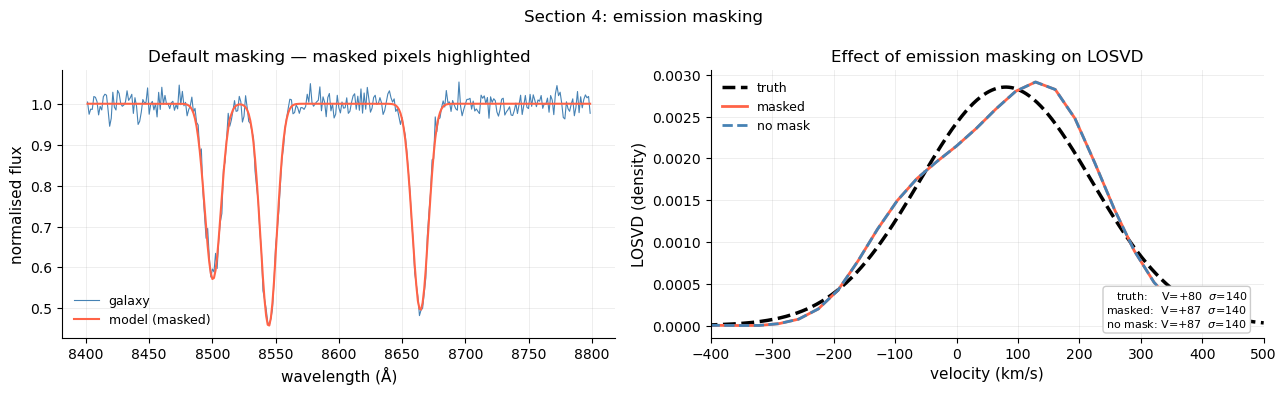

In [10]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

st_m = fit_masked['state']
st_n = fit_nomask['state']
gp_m = fit_masked['outputs']['gp']
gp_n = fit_nomask['outputs']['gp']
b_m  = fit_masked['outputs']['b']
b_n  = fit_nomask['outputs']['b']

# Panel 1: show the masked pixels on the spectrum
ax = axes[0]
ax.plot(st_m.x, st_m.g, lw=0.8, color='steelblue', label='galaxy', zorder=2)
ax.plot(st_m.x, gp_m,   lw=1.5, color='tomato', label='model (masked)')
em = st_m.emission_pre_mask
if em.any():
    ax.scatter(st_m.x[em], st_m.g[em], s=25, color='red', zorder=5,
               label=f'masked pixels (n={em.sum()})')
ax.set_xlabel('wavelength (Å)')
ax.set_ylabel('normalised flux')
ax.set_title('Default masking — masked pixels highlighted')
ax.legend(fontsize=9, framealpha=1.0, facecolor='white').set_zorder(20)

# Panel 2: LOSVD comparison
ax = axes[1]
v_dense  = np.linspace(-500, 500, 500)
b_true_d = np.exp(-0.5*((v_dense-TRUE_V)/TRUE_SIGMA)**2)
b_true_d /= np.trapezoid(b_true_d, v_dense)
ax.plot(v_dense, b_true_d, lw=2.5, color='black', ls='--', label='truth')
ax.plot(st_m.xl, b_m/np.trapezoid(b_m,st_m.xl), lw=2.0, color='tomato',    label='masked')
ax.plot(st_n.xl, b_n/np.trapezoid(b_n,st_n.xl), lw=2.0, color='steelblue', ls='--', label='no mask')
ax.text(0.97, 0.03,
        r"truth:    V=" + f"{TRUE_V:+.0f}  " + r"$\sigma$=" + f"{TRUE_SIGMA:.0f}\n"
        r"masked:  V=" + f"{gh_masked['vherm']:+.0f}  " + r"$\sigma$=" + f"{gh_masked['sherm']:.0f}\n"
        r"no mask: V=" + f"{gh_nomask['vherm']:+.0f}  " + r"$\sigma$=" + f"{gh_nomask['sherm']:.0f}",
        transform=ax.transAxes, fontsize=8, ha='right', va='bottom',
        bbox=dict(boxstyle='round', facecolor='white', alpha=1.0, edgecolor='0.8'))
ax.set_xlabel('velocity (km/s)')
ax.set_ylabel('LOSVD (density)')
ax.set_title('Effect of emission masking on LOSVD')
ax.legend(fontsize=9, loc='upper left', framealpha=1.0, facecolor='white').set_zorder(20)
ax.set_xlim(-400, 500)

plt.suptitle('Section 4: emission masking', fontsize=12)
plt.tight_layout()
plt.show()

---
## Section 5: Effect of velocity grid density

The `sigl` parameter sets the half-width of the velocity grid as a multiple of the
velocity dispersion.  Crucially, `nl` (number of bins) is set from `sigl` via:

    xl = np.linspace(-4.5 * sigl, +4.5 * sigl, nl)

So reducing `sigl` while keeping `nl` fixed makes the grid FINER.  Or, increasing `nl`
directly via `nlosvd` gives more bins over the same range.

A practical test: try several `sigl` values (changing the velocity range / bin spacing)
and see how LOSVD recovery changes.

In [11]:
# Test different xlam values to see what xlam_auto actually picks vs the xlam
# that gives the best h3/h4 accuracy. Note: the number of LOSVD bins (nl) is a
# fixed FitConfig.n_losvd_bins (default 29), not auto-derived from sigl -- widening
# losvd_vmin/vmax (e.g. via a larger sigl) widens each bin rather than adding more
# bins, at fixed nl. Set n_losvd_bins explicitly if you want a different bin count.

from kinextract.fitting import compute_losvd_roughness

THRESHOLD = 0.25
XLAM_FINE = [10., 30., 100., 300., 1000., 3000., 10000., 30000., 100000.]
fine_results = []

for xlam in XLAM_FINE:
    cfg = FitConfig(**{**BASE_CFG, 'xlam': xlam,
                       'mask_emission_lines_in_fit': False,
                       'segment_emission_mask': False})
    fit = run_spectral_fit(cfg, gal_file=str(tmpdir/'mock.spec'))
    b   = fit['outputs']['b']
    gh  = fit_losvd_gauss_hermite(fit['state'].xl, b, fit_h3h4=True)
    chi2      = fit['outputs']['chi2_red']
    roughness = compute_losvd_roughness(b)
    acc = '✓' if roughness <= THRESHOLD else '✗'
    rel = fit['result'].success
    fine_results.append(dict(xlam=xlam, b=b.copy(), gh=gh, chi2=chi2, roughness=roughness, success=rel))
    dV  = gh['vherm'] - TRUE_V
    ds  = gh['sherm'] - TRUE_SIGMA
    print(f'  xlam={xlam:>8.0f}  χ²={chi2:.3f}  rough={roughness:.4f}{acc}  '
          f'ΔV={dV:+.1f}  Δσ={ds:+.1f}  h3={gh["h3"]:+.4f}  h4={gh["h4"]:+.4f}  '
          f'{"" if rel else "[unreliable]"}')

  xlam=      10  χ²=0.955  rough=0.5607✗  ΔV=+91.5  Δσ=-48.6  h3=-0.6835  h4=+0.5347  
  xlam=      30  χ²=0.955  rough=0.5333✗  ΔV=+85.1  Δσ=-47.2  h3=-0.6072  h4=+0.4519  
  xlam=     100  χ²=0.956  rough=0.3143✗  ΔV=+77.3  Δσ=-47.2  h3=-0.5800  h4=+0.4498  
  xlam=     300  χ²=0.957  rough=0.2920✗  ΔV=+78.3  Δσ=-46.2  h3=-0.5392  h4=+0.3911  
  xlam=    1000  χ²=0.959  rough=0.1826✓  ΔV=+5.9  Δσ=-0.2  h3=-0.1411  h4=-0.2251  
  xlam=    3000  χ²=0.961  rough=0.1282✓  ΔV=+6.5  Δσ=+1.4  h3=-0.1177  h4=-0.1364  
  xlam=   10000  χ²=0.963  rough=0.0884✓  ΔV=+6.7  Δσ=-0.1  h3=-0.0839  h4=-0.0614  
  xlam=   30000  χ²=0.967  rough=0.0645✓  ΔV=+4.5  Δσ=-3.1  h3=-0.0428  h4=-0.0149  
  xlam=  100000  χ²=0.973  rough=0.0572✓  ΔV=+0.1  Δσ=-4.3  h3=+0.0036  h4=+0.0065  


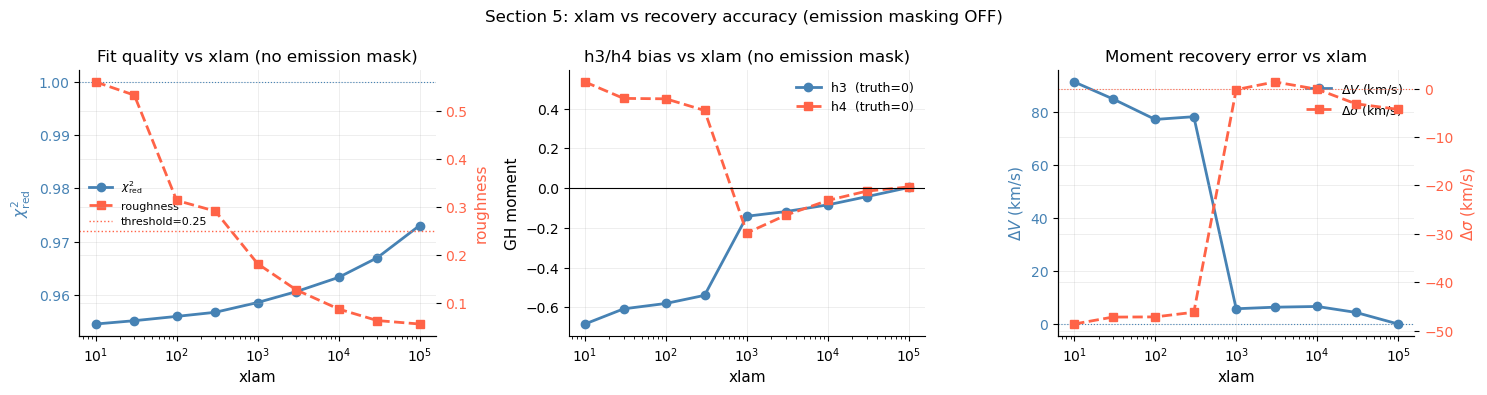

In [12]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

xlams_f    = [r['xlam']           for r in fine_results]
chi2s_f    = [r['chi2']           for r in fine_results]
roughs_f   = [r['roughness']      for r in fine_results]
dVs_f      = [r['gh']['vherm'] - TRUE_V    for r in fine_results]
dsigs_f    = [r['gh']['sherm'] - TRUE_SIGMA for r in fine_results]
h3s_f      = [r['gh']['h3']      for r in fine_results]
h4s_f      = [r['gh']['h4']      for r in fine_results]

# Panel 1: chi2 and roughness
ax  = axes[0]
ax2 = ax.twinx()
ax.semilogx(xlams_f, chi2s_f,  'o-', color='steelblue', lw=2, label=r'$\chi^2_{\rm red}$')
ax2.semilogx(xlams_f, roughs_f, 's--', color='tomato',   lw=2, label='roughness')
ax2.axhline(THRESHOLD, color='tomato', lw=1.0, ls=':', label=f'threshold={THRESHOLD}')
ax.axhline(1.0, color='steelblue', lw=0.8, ls=':')
ax.set_xlabel('xlam'); ax.set_ylabel(r'$\chi^2_{\rm red}$', color='steelblue')
ax2.set_ylabel('roughness', color='tomato')
ax.tick_params(axis='y', labelcolor='steelblue')
ax2.tick_params(axis='y', labelcolor='tomato')
l1,n1=ax.get_legend_handles_labels(); l2,n2=ax2.get_legend_handles_labels()
ax.legend(l1+l2, n1+n2, fontsize=8).set_zorder(20)
ax.set_title('Fit quality vs xlam (no emission mask)')

# Panel 2: h3 and h4 on fine grid
ax = axes[1]
ax.semilogx(xlams_f, h3s_f, 'o-', color='steelblue', lw=2, label='h3  (truth=0)')
ax.semilogx(xlams_f, h4s_f, 's--', color='tomato',  lw=2, label='h4  (truth=0)')
ax.axhline(0, lw=0.8, color='black')
ax.set_xlabel('xlam'); ax.set_ylabel('GH moment')
ax.set_title('h3/h4 bias vs xlam (no emission mask)')
ax.legend(fontsize=9).set_zorder(20)

# Panel 3: ΔV and Δσ
ax  = axes[2]
ax2 = ax.twinx()
ax.semilogx(xlams_f,  dVs_f,   'o-', color='steelblue', lw=2, label=r'$\Delta V$ (km/s)')
ax2.semilogx(xlams_f, dsigs_f, 's--', color='tomato',   lw=2, label=r'$\Delta\sigma$ (km/s)')
ax.axhline(0, lw=0.8, color='steelblue', ls=':')
ax2.axhline(0, lw=0.8, color='tomato', ls=':')
ax.set_xlabel('xlam'); ax.set_ylabel(r'$\Delta V$ (km/s)',  color='steelblue')
ax2.set_ylabel(r'$\Delta\sigma$ (km/s)', color='tomato')
ax.tick_params(axis='y', labelcolor='steelblue')
ax2.tick_params(axis='y', labelcolor='tomato')
l1,n1=ax.get_legend_handles_labels(); l2,n2=ax2.get_legend_handles_labels()
ax.legend(l1+l2, n1+n2, fontsize=9).set_zorder(20)
ax.set_title('Moment recovery error vs xlam')

plt.suptitle('Section 5: xlam vs recovery accuracy (emission masking OFF)', fontsize=12)
plt.tight_layout()
plt.show()

---
## Section 6: Recovery accuracy vs S/N and true velocity

The recovered moments depend on noise level and where the true velocity falls relative
to the xl grid.  This section sweeps S/N and true V at fixed xlam to map out the
expected accuracy envelope.

In [13]:
# Sweep true velocity — does recovery degrade when V falls between xl bins?
# xl bins are spaced ~32 km/s; test V from 0 to 96 km/s (one full bin period)
V_SWEEP   = np.arange(0, 130, 16)   # multiple of xl_step/2 covers all phases
XLAM_BEST = 1000.0                  # use a moderate xlam for this test

v_sweep_results = []
print('True V  |  Rec V   |  ΔV   |  Rec σ  |  Δσ  |  h3')
for tv in V_SWEEP:
    sp  = tv * LAM_CENTER / (CEE * STEP)
    sig_p = TRUE_SIGMA * LAM_CENTER / (CEE * STEP)
    g_i = ndimage_shift(gaussian_filter(template, sig_p), +sp)
    g_i += np.random.default_rng(int(tv*100+99)).normal(0.0, 0.02, N_PIX)
    spec_path = tmpdir / f'sweep_{int(tv):04d}.spec'
    np.savetxt(spec_path, np.column_stack([np.arange(1, N_PIX+1), g_i, errors]),
               fmt='%6d  %14.8f  %14.8f')
    cfg = FitConfig(**{**BASE_CFG, 'xlam': XLAM_BEST,
                       'mask_emission_lines_in_fit': False,
                       'segment_emission_mask': False})
    fit = run_spectral_fit(cfg, gal_file=str(spec_path))
    b_r = fit['outputs']['b']
    gh  = fit_losvd_gauss_hermite(fit['state'].xl, b_r, fit_h3h4=True)
    v_sweep_results.append(dict(tv=tv, gh=gh, success=fit['result'].success))
    flag = '' if fit['result'].success else '  [unreliable]'
    print(f'{tv:7.0f}  | {gh["vherm"]:+.1f}  | {gh["vherm"]-tv:+.1f}  | '
          f'{gh["sherm"]:.1f}  | {gh["sherm"]-TRUE_SIGMA:+.1f}  | {gh["h3"]:+.4f}{flag}')

True V  |  Rec V   |  ΔV   |  Rec σ  |  Δσ  |  h3
      0  | +18.1  | +18.1  | 115.9  | -24.1  | -0.1645
     16  | +24.0  | +8.0  | 145.6  | +5.6  | -0.0211
     32  | +35.0  | +3.0  | 145.4  | +5.4  | +0.0588
     48  | +49.6  | +1.6  | 151.0  | +11.0  | +0.0180
     64  | +63.9  | -0.1  | 138.0  | -2.0  | +0.0998
     80  | +79.8  | -0.2  | 133.8  | -6.2  | +0.0325
     96  | +93.3  | -2.7  | 143.3  | +3.3  | +0.0501
    112  | +96.8  | -15.2  | 133.7  | -6.3  | +0.1344
    128  | +135.0  | +7.0  | 135.1  | -4.9  | -0.0466


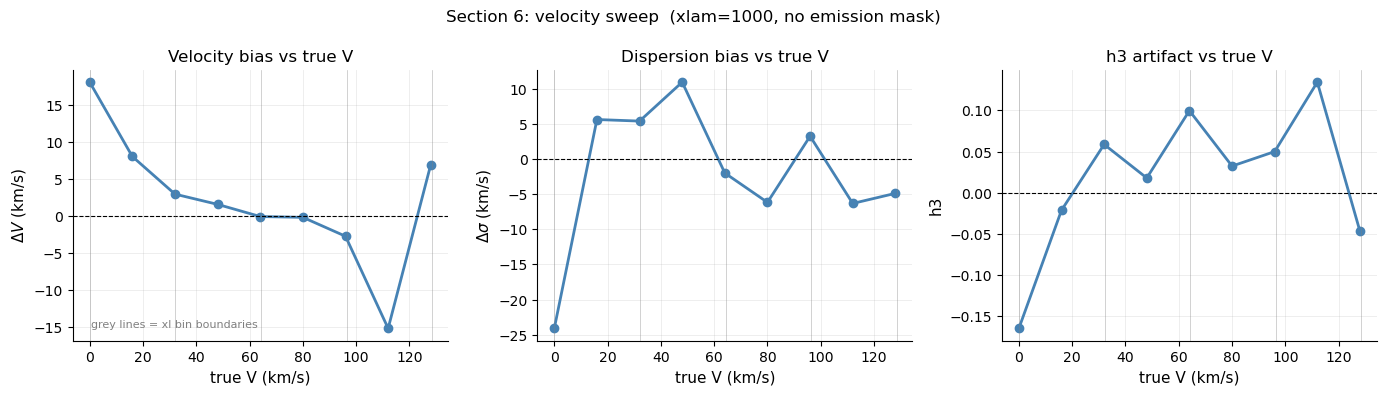

In [14]:
fig, axes = plt.subplots(1, 3, figsize=(14, 4))

tv_arr  = np.array([r['tv']               for r in v_sweep_results])
dV_arr  = np.array([r['gh']['vherm']-r['tv']  for r in v_sweep_results])
ds_arr  = np.array([r['gh']['sherm']-TRUE_SIGMA for r in v_sweep_results])
h3_arr  = np.array([r['gh']['h3']         for r in v_sweep_results])
h4_arr  = np.array([r['gh']['h4']         for r in v_sweep_results])

# Mark xl bin boundaries
xl_ticks = st.xl[(st.xl >= 0) & (st.xl <= tv_arr.max()+xl_step)]

for ax, arr, ylabel, title, truth in [
    (axes[0], dV_arr,  r'$\Delta V$ (km/s)', 'Velocity bias vs true V', 0),
    (axes[1], ds_arr,  r'$\Delta\sigma$ (km/s)', 'Dispersion bias vs true V', 0),
    (axes[2], h3_arr,  'h3', 'h3 artifact vs true V', 0),
]:
    ax.plot(tv_arr, arr, 'o-', lw=2.0, color='steelblue')
    ax.axhline(truth, lw=0.8, color='black', ls='--')
    for xt in xl_ticks:
        ax.axvline(xt, lw=0.5, color='grey', alpha=0.5)
    ax.set_xlabel('true V (km/s)')
    ax.set_ylabel(ylabel)
    ax.set_title(title)

axes[0].annotate('grey lines = xl bin boundaries', xy=(0.05, 0.05),
                 xycoords='axes fraction', fontsize=8, color='grey')

plt.suptitle(f'Section 6: velocity sweep  (xlam={XLAM_BEST:.0f}, no emission mask)', fontsize=12)
plt.tight_layout()
plt.show()

---
## Summary and recommendations

Based on the diagnostics above:

In [15]:
# Pick the xlam with the smallest |h3| + |h4| at chi2_red < 1.05
good   = [r for r in fine_results if r['chi2'] < 1.10]
best_r = min(good, key=lambda r: abs(r['gh']['h3']) + abs(r['gh']['h4']))

print('=' * 65)
print('DIAGNOSTIC SUMMARY')
print('=' * 65)
print()
print(f'Velocity grid:')
print(f'  xl step             = {xl_step:.1f} km/s')
print(f'  Data pixel scale    = {pix_kms:.1f} km/s/pixel at {LAM_CENTER:.0f} Å')
print(f'  Bins per sigma      = {sigma_bins:.1f}  (for σ={TRUE_SIGMA:.0f} km/s)')
print()
print(f'Forward model:')
print(f'  MAP residual RMS          = {resid_rms/noise_sigma:.3f} × noise σ  (chi2_red={chi2_red:.2f})')
print(f'  → forward model fits data within noise; not a source of systematic error')
print()
print(f'Regularisation (emission mask OFF):')
print(f'  Best xlam for accuracy  = {best_r["xlam"]:.0f}')
print(f'  At xlam={best_r["xlam"]:.0f}:  ΔV={best_r["gh"]["vherm"]-TRUE_V:+.1f}  Δσ={best_r["gh"]["sherm"]-TRUE_SIGMA:+.1f}  '
      f'h3={best_r["gh"]["h3"]:+.4f}  h4={best_r["gh"]["h4"]:+.4f}')
print()
print(f'Emission masking effect:')
dV_mask = gh_masked['vherm'] - gh_nomask['vherm']
print(f'  Masked pixels: {fit_masked["state"].emission_pre_mask.sum()} (of {fit_masked["state"].npix})')
print(f'  ΔV (masked vs unmasked): {dV_mask:+.1f} km/s')
print()
print('Recommendations:')
print(f'  1. xlam_smooth_threshold=0.25 may select xlam that is too large for high-S/N data')
print(f'     → consider lower threshold (e.g. 0.10–0.15) or direct xlam optimisation')
print(f'  2. Emission masking can remove ≥{fit_masked["state"].emission_pre_mask.sum()} pixels near CaII')
print(f'     → review mask_emission_line_snr_threshold (default=3.0) for mock spectra')
print(f'  3. xl_step={xl_step:.1f} km/s gives {sigma_bins:.1f} bins/σ at σ={TRUE_SIGMA} km/s — adequate but not fine')
print(f'     → smaller sigl or custom xl grid would improve resolution at low σ')

DIAGNOSTIC SUMMARY

Velocity grid:
  xl step             = 32.1 km/s
  Data pixel scale    = 43.7 km/s/pixel at 8580 Å
  Bins per sigma      = 4.4  (for σ=140 km/s)

Forward model:
  MAP residual RMS          = 0.980 × noise σ  (chi2_red=0.96)
  → forward model fits data within noise; not a source of systematic error

Regularisation (emission mask OFF):
  Best xlam for accuracy  = 100000
  At xlam=100000:  ΔV=+0.1  Δσ=-4.3  h3=+0.0036  h4=+0.0065

Emission masking effect:
  Masked pixels: 0 (of 319)
  ΔV (masked vs unmasked): +0.0 km/s

Recommendations:
  1. xlam_smooth_threshold=0.25 may select xlam that is too large for high-S/N data
     → consider lower threshold (e.g. 0.10–0.15) or direct xlam optimisation
  2. Emission masking can remove ≥0 pixels near CaII
     → review mask_emission_line_snr_threshold (default=3.0) for mock spectra
  3. xl_step=32.1 km/s gives 4.4 bins/σ at σ=140.0 km/s — adequate but not fine
     → smaller sigl or custom xl grid would improve resolution at lo